# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 18 — 2026 Final Holdout Evaluation & Research Lockbox

**Purpose:** open the previously untouched 2026 holdout for the first time and evaluate the research architecture frozen through Notebook 17.

### Frozen decisions entering the holdout

- **Signal engine:** unchanged.
- **Equity Early Reversal:** `ER_2_STEP` — 50% of target exposure on the Early-Reversal start week and the remaining 50% one week later, provided the position remains active.
- **Non-equity Early Reversal:** immediate entry.
- **Pullback Accumulation:** `PB_HOLD_100` — no systematic overweight during pullbacks.
- **Profit-Taking:** unchanged.
- **Long/cash architecture:** unchanged.
- **Portfolio construction:** hierarchical inverse-volatility research specification; not re-optimised here.
- **Transaction-cost assumption:** 5 bps one-way.
- **Research sample:** through 31 December 2025.
- **Final holdout:** from 1 January 2026 onward.

This notebook is **evaluation only**. No 2026 observation may be used to alter a rule, choose a parameter, select a weighting method, or reopen a rejected architecture.

Once this notebook successfully reads 2026 data, the holdout is permanently considered **ACCESSED**.

In [1]:
# ============================================================
# 18.1 — IMPORTS, DRIVE MOUNT, GLOBAL SETTINGS
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy"
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_18"
MANIFEST_DIR = PROJECT_ROOT / "manifests"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_END = pd.Timestamp("2025-12-31")
HOLDOUT_START = pd.Timestamp("2026-01-01")
WEEKS_PER_YEAR = 52.0
BASE_ONE_WAY_COST_BPS = 5.0

ASSET_CLASS_MAP = {
    "SPY": "equities", "EFA": "equities", "EEM": "equities",
    "SHY": "rates", "IEF": "rates", "TLT": "rates", "TIP": "rates",
    "GLD": "commodities", "DBC": "commodities",
    "UUP": "fx",
    "BTC-USD": "crypto",
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("Holdout start:", HOLDOUT_START.date())
print("Notebook 18 mode: FINAL HOLDOUT — NO OPTIMISATION")

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
Holdout start: 2026-01-01
Notebook 18 mode: FINAL HOLDOUT — NO OPTIMISATION


## 18.2 Research lock

The following comparisons are **diagnostic counterfactuals**, not competing candidates:

1. `ORIGINAL_IMMEDIATE` — the pre-Notebook-14 equity Early-Reversal implementation: immediate entry, with no pullback overweight.
2. `FINAL_FROZEN` — the architecture accepted before opening the holdout: equity Early-Reversal 2-step 50/50, all other Early-Reversal entries immediate, and `PB_HOLD_100`.
3. `ER_EFFECT` — `FINAL_FROZEN − ORIGINAL_IMMEDIATE`, isolating the only accepted sizing modification that changes these reconstructed instrument returns.

Notebook 17's decision not to add during pullbacks is represented by both architectures using `PB_HOLD_100`. Rejected pullback-add variants are deliberately **not run on 2026**, preventing the holdout from becoming another model-selection sample.

In [2]:
# ============================================================
# 18.3 — VERIFY PRE-HOLDOUT RESEARCH MANIFESTS
# ============================================================

manifest_16 = MANIFEST_DIR / "16_integrated_equity_2step_manifest.json"
manifest_17 = MANIFEST_DIR / "17_pullback_accumulation_architecture_manifest.json"

def load_json_if_exists(path):
    if path.exists():
        with open(path, "r") as f:
            return json.load(f)
    return None

m16 = load_json_if_exists(manifest_16)
m17 = load_json_if_exists(manifest_17)

print("Notebook 16 manifest:", "FOUND" if m16 else "not found — continuing with hard-coded frozen rule")
print("Notebook 17 manifest:", "FOUND" if m17 else "not found — continuing with hard-coded frozen rule")

if m17 is not None:
    assert m17.get("holdout_accessed") is False, "Notebook 17 manifest says holdout was already accessed."
    assert str(m17.get("research_end")) == "2025-12-31", "Unexpected Notebook 17 research cutoff."

FROZEN_RULES = {
    "equity_early_reversal": "2-step 50/50",
    "non_equity_early_reversal": "immediate",
    "pullback": "PB_HOLD_100",
    "one_way_cost_bps": BASE_ONE_WAY_COST_BPS,
}

display(pd.DataFrame(
    [{"rule": k, "frozen_value": v} for k, v in FROZEN_RULES.items()]
))

Notebook 16 manifest: FOUND
Notebook 17 manifest: FOUND


,rule,frozen_value
0,equity_early_reversal,2-step 50/50
1,non_equity_early_reversal,immediate
2,pullback,PB_HOLD_100
3,one_way_cost_bps,5.0


In [3]:
# ============================================================
# 18.4 — LOCATE THE FULL SIGNAL PANEL
# ============================================================

def find_first_existing(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None

def recursive_find(patterns):
    hits = []
    for pat in patterns:
        hits.extend(PROJECT_ROOT.rglob(pat))
    return sorted(set(hits))

SIGNAL_PATH = find_first_existing([
    DATA_PROCESSED / "superbcommand_weekly_signal_panel.parquet",
    DATA_PROCESSED / "superbcommand_signal_panel.parquet",
])

if SIGNAL_PATH is None:
    hits = recursive_find([
        "*superbcommand*weekly*signal*panel*.parquet",
        "*superbcommand*signal*panel*.parquet",
        "*signal*panel*.parquet",
    ])
    SIGNAL_PATH = hits[0] if hits else None

if SIGNAL_PATH is None:
    raise FileNotFoundError("Could not locate the SuperbCommand weekly signal panel.")

print("Selected signal panel:")
print(SIGNAL_PATH)

Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet


In [4]:
# ============================================================
# 18.5 — LOAD, NORMALISE, AND OPEN THE 2026 LOCKBOX
# ============================================================

sig = pd.read_parquet(SIGNAL_PATH).copy()

if "ticker" not in sig.columns:
    if isinstance(sig.index, pd.MultiIndex) and "ticker" in sig.index.names:
        sig = sig.reset_index()
    elif sig.index.name == "ticker":
        sig = sig.reset_index()

if "date" not in sig.columns:
    if isinstance(sig.index, pd.MultiIndex) and "date" in sig.index.names:
        sig = sig.reset_index()
    elif sig.index.name == "date":
        sig = sig.reset_index()

if "ticker" not in sig.columns or "date" not in sig.columns:
    raise KeyError(
        f"Could not recover ticker/date. Columns={list(sig.columns)}; index={sig.index.names}"
    )

sig["date"] = pd.to_datetime(sig["date"])

if "asset_class" not in sig.columns:
    sig["asset_class"] = sig["ticker"].map(ASSET_CLASS_MAP)

unmapped = sorted(
    sig.loc[sig["asset_class"].isna(), "ticker"]
       .dropna().astype(str).unique().tolist()
)
if unmapped:
    raise KeyError(f"Unmapped ticker(s): {unmapped}")

required = [
    "ticker", "date", "asset_class", "close",
    "position_held", "early_reversal_active", "start_early_reversal",
    "pullback_active", "profit_taking_active"
]
missing = [c for c in required if c not in sig.columns]
if missing:
    raise KeyError(f"Missing required signal columns: {missing}")

sig = sig.sort_values(["ticker", "date"]).reset_index(drop=True)

holdout_raw = sig[sig["date"] >= HOLDOUT_START].copy()

if holdout_raw.empty:
    raise RuntimeError(
        "No 2026 observations are present in the signal panel. "
        "Refresh the upstream data/signal notebooks before opening the final holdout."
    )

print("=" * 78)
print("2026 HOLDOUT ACCESSED")
print("=" * 78)
print("First holdout date:", holdout_raw["date"].min().date())
print("Latest holdout date:", holdout_raw["date"].max().date())
print("Holdout rows:", len(holdout_raw))
print("Holdout tickers:", holdout_raw["ticker"].nunique())
print()
print("IMPORTANT: from this point onward, 2026 is SEEN DATA for this research version.")

2026 HOLDOUT ACCESSED
First holdout date: 2026-01-02
Latest holdout date: 2026-09-04
Holdout rows: 396
Holdout tickers: 11

IMPORTANT: from this point onward, 2026 is SEEN DATA for this research version.


In [5]:
# ============================================================
# 18.6 — RECONSTRUCT WEEKLY UNDERLYING RETURNS WITHOUT LOOKAHEAD
# ============================================================

# Return dated t is close_t / close_(t-1) - 1.
# Exposure used for that return must therefore be the exposure known at t-1.
sig["underlying_return"] = (
    sig.groupby("ticker", observed=True)["close"]
       .pct_change()
       .replace([np.inf, -np.inf], np.nan)
)

print("Underlying return observations:", sig["underlying_return"].notna().sum())

Underlying return observations: 11755


In [6]:
# ============================================================
# 18.7 — BUILD ORIGINAL AND FROZEN EXPOSURE PATHS
# ============================================================

base_held = sig["position_held"].fillna(False).astype(bool).astype(float)

# Original architecture: full exposure whenever position_held is true.
sig["exp_original"] = base_held.copy()

# Final architecture starts identically.
sig["exp_final"] = base_held.copy()

# Accepted Notebook 14–16 modification:
# equities enter Early Reversal in two 50/50 steps.
is_eq = sig["asset_class"].eq("equities")
er_active = sig["early_reversal_active"].fillna(False).astype(bool)
er_start = sig["start_early_reversal"].fillna(False).astype(bool)

# First ER week receives 50%.
first_step = is_eq & er_active & er_start & base_held.eq(1.0)
sig.loc[first_step, "exp_final"] = 0.50

# Defensive handling for datasets where start flag and active flag can differ:
# the first active ER observation within each contiguous ER episode is also 50%.
prev_er = (
    er_active.groupby(sig["ticker"], observed=True)
             .shift(1)
             .fillna(False)
)
episode_start = is_eq & er_active & (~prev_er) & base_held.eq(1.0)
sig.loc[episode_start, "exp_final"] = 0.50

# Subsequent ER weeks remain at full target exposure.
# Pullbacks remain PB_HOLD_100: no exposure increase is applied.

assert sig["exp_original"].between(0, 1).all()
assert sig["exp_final"].between(0, 1).all()

print("Equity ER first-step observations:", int((first_step | episode_start).sum()))
display(
    sig.loc[first_step | episode_start,
            ["ticker","date","asset_class","early_reversal_active",
             "start_early_reversal","exp_original","exp_final"]].tail(20)
)

Equity ER first-step observations: 22


,ticker,date,asset_class,early_reversal_active,start_early_reversal,exp_original,exp_final
2067,EEM,2012-01-27,equities,True,True,1.0,0.5
2283,EEM,2016-03-18,equities,True,True,1.0,0.5
2442,EEM,2019-04-05,equities,True,True,1.0,0.5
2633,EEM,2022-12-02,equities,True,True,1.0,0.5
2949,EFA,2007-04-20,equities,True,True,1.0,0.5
3056,EFA,2009-05-08,equities,True,True,1.0,0.5
3230,EFA,2012-09-07,equities,True,True,1.0,0.5
3360,EFA,2015-03-06,equities,True,True,1.0,0.5
3419,EFA,2016-04-22,equities,True,True,1.0,0.5
3568,EFA,2019-03-01,equities,True,True,1.0,0.5


In [7]:
# ============================================================
# 18.8 — APPLY ONE-WEEK IMPLEMENTATION LAG AND COSTS
# ============================================================

for col in ["exp_original", "exp_final"]:
    sig[col + "_lag"] = (
        sig.groupby("ticker", observed=True)[col]
           .shift(1)
           .fillna(0.0)
    )

    sig[col + "_turnover"] = (
        sig.groupby("ticker", observed=True)[col + "_lag"]
           .diff()
           .abs()
    )

    # First observed lagged position for each ticker.
    first_obs = sig.groupby("ticker", observed=True).cumcount().eq(0)
    sig.loc[first_obs, col + "_turnover"] = sig.loc[first_obs, col + "_lag"].abs()
    sig[col + "_turnover"] = sig[col + "_turnover"].fillna(0.0)

one_way_cost = BASE_ONE_WAY_COST_BPS / 10_000.0

sig["ret_original_instrument"] = (
    sig["exp_original_lag"] * sig["underlying_return"]
    - sig["exp_original_turnover"] * one_way_cost
)

sig["ret_final_instrument"] = (
    sig["exp_final_lag"] * sig["underlying_return"]
    - sig["exp_final_turnover"] * one_way_cost
)

sig["ret_er_effect_instrument"] = (
    sig["ret_final_instrument"] - sig["ret_original_instrument"]
)

In [8]:
# ============================================================
# 18.9 — RECONSTRUCT FROZEN HIERARCHICAL INVERSE-VOL WEIGHTS
# ============================================================

# Volatility is estimated only from information available before each return.
# 26-week rolling window, shifted one week.
sig["vol26"] = (
    sig.groupby("ticker", observed=True)["underlying_return"]
       .transform(lambda s: s.rolling(26, min_periods=13).std().shift(1))
)

# Expanding fallback also uses only prior observations.
sig["vol_expanding"] = (
    sig.groupby("ticker", observed=True)["underlying_return"]
       .transform(lambda s: s.expanding(min_periods=4).std().shift(1))
)

sig["vol_est"] = sig["vol26"].fillna(sig["vol_expanding"])

# Final fallback is cross-sectional median at that date, then 1.0 if necessary.
date_med = sig.groupby("date", observed=True)["vol_est"].transform("median")
sig["vol_est"] = sig["vol_est"].fillna(date_med).fillna(1.0).clip(lower=1e-8)
sig["inv_vol"] = 1.0 / sig["vol_est"]

# Equal risk allocation across asset classes; inverse-vol within class.
class_sum = sig.groupby(["date","asset_class"], observed=True)["inv_vol"].transform("sum")
sig["within_class_weight"] = sig["inv_vol"] / class_sum

n_classes = (
    sig.groupby("date", observed=True)["asset_class"]
       .transform("nunique")
       .clip(lower=1)
)
sig["weight"] = sig["within_class_weight"] / n_classes

weight_check = sig.groupby("date", observed=True)["weight"].sum()
print("Weight-sum range:", float(weight_check.min()), "to", float(weight_check.max()))

Weight-sum range: 0.9999999999999999 to 1.0


In [9]:
# ============================================================
# 18.10 — BUILD PORTFOLIO RETURNS
# ============================================================

sig["original_contribution"] = sig["weight"] * sig["ret_original_instrument"]
sig["final_contribution"] = sig["weight"] * sig["ret_final_instrument"]
sig["er_effect_contribution"] = sig["weight"] * sig["ret_er_effect_instrument"]

portfolio = pd.DataFrame({
    "ORIGINAL_IMMEDIATE": sig.groupby("date", observed=True)["original_contribution"].sum(min_count=1),
    "FINAL_FROZEN": sig.groupby("date", observed=True)["final_contribution"].sum(min_count=1),
    "ER_EFFECT": sig.groupby("date", observed=True)["er_effect_contribution"].sum(min_count=1),
}).sort_index()

# Strictly evaluate holdout dates only.
holdout = portfolio.loc[portfolio.index >= HOLDOUT_START].copy()

if holdout.empty:
    raise RuntimeError("Portfolio reconstruction produced no 2026 holdout returns.")

display(holdout.head())
print("Holdout weeks:", len(holdout))
print("Latest evaluated week:", holdout.index.max().date())

,ORIGINAL_IMMEDIATE,FINAL_FROZEN,ER_EFFECT
date,,,
2026-01-02,0.002552,0.002552,0.0
2026-01-09,0.012457,0.012457,0.0
2026-01-16,0.003965,0.003965,0.0
2026-01-23,0.009762,0.009762,0.0
2026-01-30,-0.000293,-0.000293,0.0


Holdout weeks: 36
Latest evaluated week: 2026-09-04


In [10]:
# ============================================================
# 18.11 — PERFORMANCE FUNCTIONS
# ============================================================

def max_drawdown_from_returns(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1.0 + r).cumprod()
    return float((wealth / wealth.cummax() - 1.0).min())

def perf_stats(r):
    r = pd.Series(r).dropna()
    n = len(r)
    if n == 0:
        return {k: np.nan for k in [
            "weeks","total_return","annualised_return","ann_vol","sharpe",
            "sortino","max_drawdown","calmar","best_week","worst_week",
            "positive_week_rate"
        ]}

    total = (1.0 + r).prod() - 1.0
    annualised_return = (1.0 + total) ** (WEEKS_PER_YEAR / n) - 1.0
    ann_vol = r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)

    sharpe = (
        r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
        if r.std(ddof=1) > 0 else np.nan
    )

    downside = r[r < 0].std(ddof=1)
    sortino = (
        r.mean() / downside * np.sqrt(WEEKS_PER_YEAR)
        if pd.notna(downside) and downside > 0 else np.nan
    )

    mdd = max_drawdown_from_returns(r)
    calmar = annualised_return / abs(mdd) if pd.notna(mdd) and mdd < 0 else np.nan

    return {
        "weeks": n,
        "total_return": total,
        "annualised_return": annualised_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": mdd,
        "calmar": calmar,
        "best_week": r.max(),
        "worst_week": r.min(),
        "positive_week_rate": (r > 0).mean(),
    }

In [11]:
# ============================================================
# 18.12 — 2026 YTD FINAL HOLDOUT SCORECARD
# ============================================================

rows = []
for name in ["ORIGINAL_IMMEDIATE", "FINAL_FROZEN"]:
    rows.append({"architecture": name, **perf_stats(holdout[name])})

holdout_performance = pd.DataFrame(rows)
display(holdout_performance)

base = holdout_performance.set_index("architecture").loc["ORIGINAL_IMMEDIATE"]
final = holdout_performance.set_index("architecture").loc["FINAL_FROZEN"]

delta_metrics = [
    "total_return","annualised_return","ann_vol","sharpe","sortino",
    "max_drawdown","calmar","best_week","worst_week","positive_week_rate"
]

holdout_deltas = pd.DataFrame({
    "metric": delta_metrics,
    "final_frozen": [final[m] for m in delta_metrics],
    "original_immediate": [base[m] for m in delta_metrics],
    "delta_final_minus_original": [final[m] - base[m] for m in delta_metrics],
})

display(holdout_deltas)

,architecture,weeks,total_return,annualised_return,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,ORIGINAL_IMMEDIATE,36,0.09,0.132558,0.043685,2.874162,3.223936,-0.019864,6.67314,0.012457,-0.015368,0.694444
1,FINAL_FROZEN,36,0.09,0.132558,0.043685,2.874162,3.223936,-0.019864,6.67314,0.012457,-0.015368,0.694444


,metric,final_frozen,original_immediate,delta_final_minus_original
0,total_return,0.090000,0.090000,0.0
1,annualised_return,0.132558,0.132558,0.0
2,ann_vol,0.043685,0.043685,0.0
3,sharpe,2.874162,2.874162,0.0
4,sortino,3.223936,3.223936,0.0
5,max_drawdown,-0.019864,-0.019864,0.0
6,calmar,6.673140,6.673140,0.0
7,best_week,0.012457,0.012457,0.0
8,worst_week,-0.015368,-0.015368,0.0
9,positive_week_rate,0.694444,0.694444,0.0


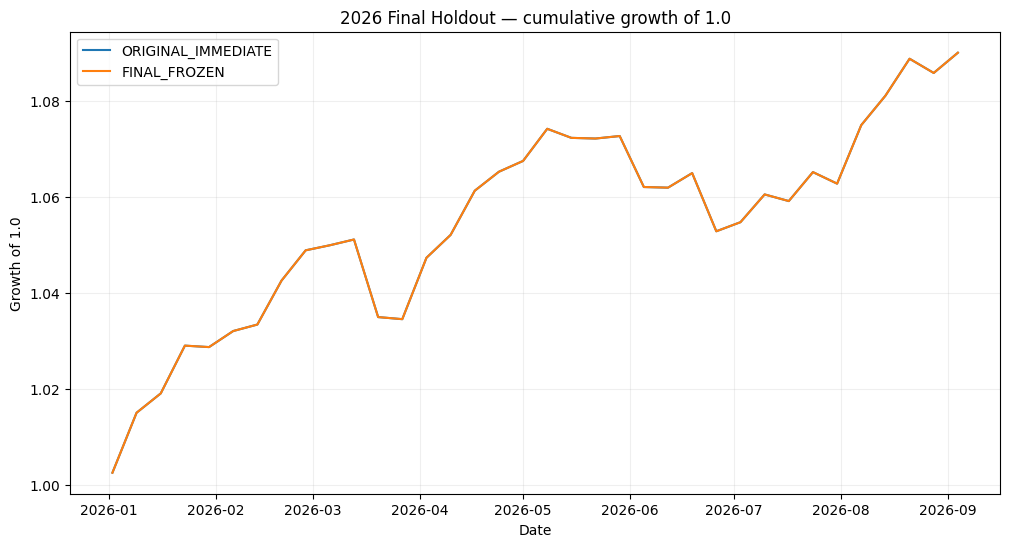

In [12]:
# ============================================================
# 18.13 — CUMULATIVE WEALTH
# ============================================================

wealth = (1.0 + holdout[["ORIGINAL_IMMEDIATE","FINAL_FROZEN"]].fillna(0)).cumprod()

plt.figure(figsize=(12,6))
for c in wealth.columns:
    plt.plot(wealth.index, wealth[c], label=c)
plt.title("2026 Final Holdout — cumulative growth of 1.0")
plt.xlabel("Date")
plt.ylabel("Growth of 1.0")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

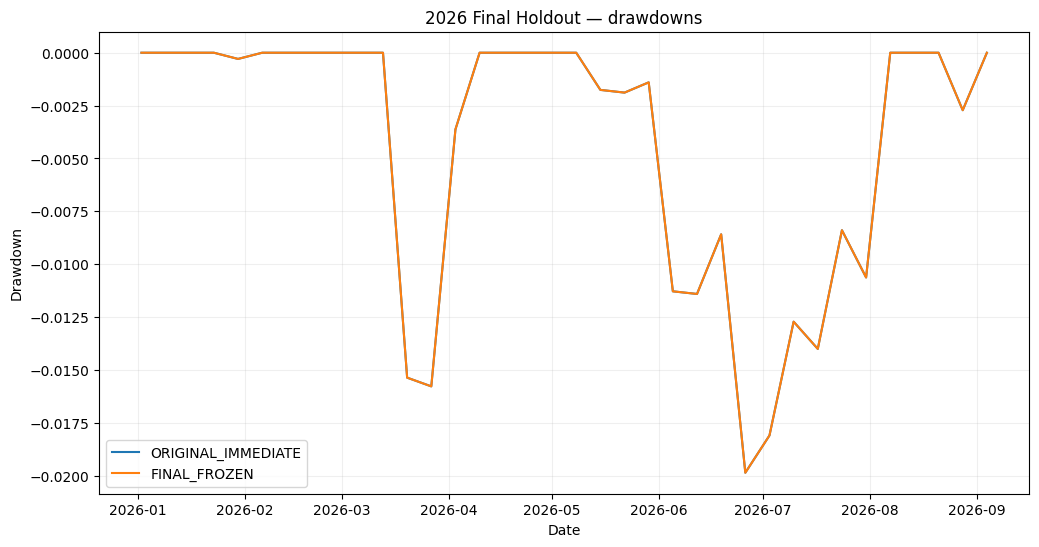

In [13]:
# ============================================================
# 18.14 — DRAWDOWN COMPARISON
# ============================================================

dd = wealth.div(wealth.cummax()).sub(1.0)

plt.figure(figsize=(12,6))
for c in dd.columns:
    plt.plot(dd.index, dd[c], label=c)
plt.title("2026 Final Holdout — drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [14]:
# ============================================================
# 18.15 — ACCEPTED-RULE ATTRIBUTION
# ============================================================

# Because PB_HOLD_100 is common to both portfolios, the direct return difference
# isolates the accepted equity ER pacing modification.
attribution = pd.DataFrame({
    "date": holdout.index,
    "equity_er_2step_effect": holdout["ER_EFFECT"].values,
})

attribution["cumulative_arithmetic_effect"] = attribution["equity_er_2step_effect"].cumsum()

attr_summary = pd.DataFrame([{
    "modification": "Equity Early-Reversal 2-step 50/50 vs immediate",
    "holdout_weeks": attribution["equity_er_2step_effect"].notna().sum(),
    "mean_weekly_effect": attribution["equity_er_2step_effect"].mean(),
    "annualised_arithmetic_effect_approx":
        attribution["equity_er_2step_effect"].mean() * WEEKS_PER_YEAR,
    "positive_effect_week_rate":
        (attribution["equity_er_2step_effect"] > 0).mean(),
    "cumulative_arithmetic_effect":
        attribution["equity_er_2step_effect"].sum(),
}])

display(attr_summary)

,modification,holdout_weeks,mean_weekly_effect,annualised_arithmetic_effect_approx,positive_effect_week_rate,cumulative_arithmetic_effect
0,Equity Early-Reversal 2-step 50/50 vs immediate,36,0.0,0.0,0.0,0.0


In [15]:
# ============================================================
# 18.16 — ASSET-CLASS ATTRIBUTION
# ============================================================

h = sig[sig["date"] >= HOLDOUT_START].copy()

asset_attr = (
    h.groupby("asset_class", observed=True)
     .agg(
         weeks=("date","nunique"),
         original_return_contribution=("original_contribution","sum"),
         final_return_contribution=("final_contribution","sum"),
         er_2step_effect=("er_effect_contribution","sum"),
     )
     .reset_index()
)

display(asset_attr.sort_values("er_2step_effect", ascending=False))

,asset_class,weeks,original_return_contribution,final_return_contribution,er_2step_effect
0,commodities,36,0.039395,0.039395,0.0
1,crypto,36,0.007219,0.007219,0.0
2,equities,36,0.032311,0.032311,0.0
3,fx,36,0.008324,0.008324,0.0
4,rates,36,-0.000326,-0.000326,0.0


In [16]:
# ============================================================
# 18.17 — TICKER-LEVEL ATTRIBUTION
# ============================================================

ticker_attr = (
    h.groupby(["ticker","asset_class"], observed=True)
     .agg(
         weeks=("date","nunique"),
         original_return_contribution=("original_contribution","sum"),
         final_return_contribution=("final_contribution","sum"),
         er_2step_effect=("er_effect_contribution","sum"),
     )
     .reset_index()
     .sort_values("er_2step_effect", ascending=False)
)

display(ticker_attr)

,ticker,asset_class,weeks,original_return_contribution,final_return_contribution,er_2step_effect
0,BTC-USD,crypto,36,0.007219,0.007219,0.0
1,DBC,commodities,36,0.040702,0.040702,0.0
2,EEM,equities,36,0.013485,0.013485,0.0
3,EFA,equities,36,0.008701,0.008701,0.0
4,GLD,commodities,36,-0.001307,-0.001307,0.0
5,IEF,rates,36,-0.000259,-0.000259,0.0
6,SHY,rates,36,0.000261,0.000261,0.0
7,SPY,equities,36,0.010126,0.010126,0.0
8,TIP,rates,36,0.000191,0.000191,0.0
9,TLT,rates,36,-0.000519,-0.000519,0.0


In [17]:
# ============================================================
# 18.18 — 2026 EARLY-REVERSAL EVENT AUDIT
# ============================================================

events_2026 = h[
    h["asset_class"].eq("equities")
    & (
        h["start_early_reversal"].fillna(False).astype(bool)
        | (
            h["early_reversal_active"].fillna(False).astype(bool)
            & ~h.groupby("ticker", observed=True)["early_reversal_active"]
                .shift(1).fillna(False).astype(bool)
        )
    )
].copy()

event_cols = [
    "ticker","date","asset_class","close","position_held",
    "early_reversal_active","start_early_reversal",
    "exp_original","exp_final"
]

print("2026 equity Early-Reversal starts:", len(events_2026))
display(events_2026[event_cols])

2026 equity Early-Reversal starts: 0


,ticker,date,asset_class,close,position_held,early_reversal_active,start_early_reversal,exp_original,exp_final


In [18]:
# ============================================================
# 18.19 — WEEKLY DIFFERENCE AUDIT
# ============================================================

weekly_diff = holdout[["ORIGINAL_IMMEDIATE","FINAL_FROZEN","ER_EFFECT"]].copy()
weekly_diff["abs_effect"] = weekly_diff["ER_EFFECT"].abs()

display(
    weekly_diff.sort_values("abs_effect", ascending=False).head(20)
)

,ORIGINAL_IMMEDIATE,FINAL_FROZEN,ER_EFFECT,abs_effect
date,,,,
2026-01-02,0.002552,0.002552,0.0,0.0
2026-01-09,0.012457,0.012457,0.0,0.0
2026-01-16,0.003965,0.003965,0.0,0.0
2026-01-23,0.009762,0.009762,0.0,0.0
2026-01-30,-0.000293,-0.000293,0.0,0.0
2026-02-06,0.003247,0.003247,0.0,0.0
2026-02-13,0.001310,0.001310,0.0,0.0
2026-02-20,0.008851,0.008851,0.0,0.0
2026-02-27,0.006052,0.006052,0.0,0.0


## 18.20 Holdout interpretation protocol

The outcome is recorded, not optimised.

- If `FINAL_FROZEN` beats `ORIGINAL_IMMEDIATE`, this is supportive genuinely out-of-sample evidence.
- If it loses, that is a genuine holdout loss and **does not trigger a rule reversal**.
- Rejected pullback-add architectures are not inspected on 2026.
- No parameter, asset-class exception, timing rule, or weighting change may be selected because of a 2026 result.
- Any new idea motivated by the holdout belongs to a separately versioned future research programme.

The objective is therefore not to obtain a favourable 2026 result. The objective is to obtain an **honest** one.

In [19]:
# ============================================================
# 18.21 — SAVE HOLDOUT OUTPUTS
# ============================================================

holdout.to_parquet(
    RESULTS_DIR / "18_2026_holdout_portfolio_returns.parquet"
)
holdout_performance.to_csv(
    RESULTS_DIR / "18_2026_holdout_performance.csv",
    index=False
)
holdout_deltas.to_csv(
    RESULTS_DIR / "18_2026_holdout_deltas.csv",
    index=False
)
attribution.to_csv(
    RESULTS_DIR / "18_2026_equity_er_attribution_weekly.csv",
    index=False
)
attr_summary.to_csv(
    RESULTS_DIR / "18_2026_equity_er_attribution_summary.csv",
    index=False
)
asset_attr.to_csv(
    RESULTS_DIR / "18_2026_asset_class_attribution.csv",
    index=False
)
ticker_attr.to_csv(
    RESULTS_DIR / "18_2026_ticker_attribution.csv",
    index=False
)
events_2026[event_cols].to_csv(
    RESULTS_DIR / "18_2026_equity_er_events.csv",
    index=False
)

print("Outputs written to:", RESULTS_DIR)

Outputs written to: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/notebook_18


In [20]:
# ============================================================
# 18.22 — FINAL HOLDOUT VALIDATION SUITE
# ============================================================

checks = {
    "signal_panel_loaded": bool(len(sig) > 0),
    "pre_2026_history_exists": bool((sig["date"] <= RESEARCH_END).any()),
    "2026_holdout_exists": bool((sig["date"] >= HOLDOUT_START).any()),
    "holdout_begins_2026_or_later": bool(holdout.index.min() >= HOLDOUT_START),
    "holdout_has_no_pre_2026_rows": bool((holdout.index.year >= 2026).all()),
    "original_and_final_present": {
        "ORIGINAL_IMMEDIATE","FINAL_FROZEN"
    }.issubset(holdout.columns),
    "equity_2step_implemented": bool(
        ((sig["asset_class"] == "equities") & (sig["exp_final"] == 0.5)).any()
    ),
    "no_pullback_overweight": bool(sig["exp_final"].max() <= 1.0),
    "weights_finite": bool(np.isfinite(sig["weight"]).all()),
    "holdout_returns_finite": bool(
        np.isfinite(
            holdout[["ORIGINAL_IMMEDIATE","FINAL_FROZEN"]].dropna().values
        ).all()
    ),
    "outputs_written": bool(
        (RESULTS_DIR / "18_2026_holdout_performance.csv").exists()
        and (RESULTS_DIR / "18_2026_equity_er_attribution_summary.csv").exists()
    ),
}

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})
display(validation)

failed = [k for k,v in checks.items() if not v]
if failed:
    raise RuntimeError(f"Notebook 18 validation failed: {failed}")

print("\n" + "="*78)
print("NOTEBOOK 18 STATUS: PASS")
print("="*78)
print("2026 FINAL HOLDOUT: ACCESSED")
print("Architecture status: PERMANENTLY FROZEN FOR THIS RESEARCH VERSION")
print("No 2026-based model selection is permitted.")

,check,passed
0,signal_panel_loaded,True
1,pre_2026_history_exists,True
2,2026_holdout_exists,True
3,holdout_begins_2026_or_later,True
4,holdout_has_no_pre_2026_rows,True
5,original_and_final_present,True
6,equity_2step_implemented,True
7,no_pullback_overweight,True
8,weights_finite,True
9,holdout_returns_finite,True



NOTEBOOK 18 STATUS: PASS
2026 FINAL HOLDOUT: ACCESSED
Architecture status: PERMANENTLY FROZEN FOR THIS RESEARCH VERSION
No 2026-based model selection is permitted.


In [21]:
# ============================================================
# 18.23 — WRITE PERMANENT RESEARCH-LOCK MANIFEST
# ============================================================

manifest = {
    "notebook_id": "18",
    "notebook_name": "2026 Final Holdout Evaluation & Research Lockbox",
    "project_name": "SuperbCommand - Multi-Asset CTA Strategy",
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_first_observation": str(holdout.index.min().date()),
    "holdout_latest_observation": str(holdout.index.max().date()),
    "holdout_accessed": True,
    "holdout_accessed_in_notebook": 18,
    "architecture_permanently_frozen": True,
    "frozen_rules": FROZEN_RULES,
    "counterfactuals_run": [
        "ORIGINAL_IMMEDIATE",
        "FINAL_FROZEN",
    ],
    "rejected_pullback_architectures_run_on_holdout": False,
    "signal_hyperparameters_optimised_on_holdout": False,
    "portfolio_weighting_reoptimised_on_holdout": False,
    "one_way_cost_bps": BASE_ONE_WAY_COST_BPS,
    "outputs_dir": str(RESULTS_DIR),
    "status": "PASS" if all(checks.values()) else "FAIL",
    "research_lock": (
        "2026 is seen data from Notebook 18 onward and must not be used "
        "to modify this version of the strategy."
    ),
}

manifest_path = (
    MANIFEST_DIR / "18_2026_final_holdout_research_lock_manifest.json"
)

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("Permanent holdout manifest written:")
print(manifest_path)

Permanent holdout manifest written:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/18_2026_final_holdout_research_lock_manifest.json


---

# End of Notebook 18

## Most useful outputs to send back

Please send the outputs/screenshots from:

1. **18.5** — actual first/latest 2026 dates and number of holdout rows;
2. **18.12** — final holdout performance and delta tables;
3. **18.13–18.14** — cumulative wealth and drawdown charts;
4. **18.15** — accepted equity 2-step attribution;
5. **18.16–18.17** — asset-class and ticker attribution;
6. **18.18** — 2026 equity Early-Reversal events;
7. **18.22** — validation suite.

The central question is now deliberately narrow:

> **Did the architecture selected without seeing 2026 behave as expected when exposed to genuinely unseen 2026 data?**

Whatever the answer, the architecture is not changed in this notebook.